## 0. Introduction

The aim of this lab is to get familiar with **classification problems** and **logistic regression**. We will be using some code extracts that were implemented last week and build a logistic regression model.

1.   This lab is the second course-work activity **Assignment 1 Part 2: Classification**
2. Assignment 1 is split into 3 parts: Part 1 - Regression (Lab 3), and Part 2 - Classification (Lab 4) and Part 3 - Neural Networks (Lab 6). The three parts need to be submitted together by  **Monday, 11th November 2024, 10:00am**
3. All questions need to be completed and are assessed.
4. For each lab, a report answering the <font color = 'red'>**questions in red**</font> should be included along with the completed Notebook (.ipynb)
5. The report should be a separate file in **pdf format** (so **NOT** *doc, docx, notebook* etc.).
6. Make sure that **any figures or code** you comment on, are **included in the report**.
7. There are three parts of Assignment 1, therefore you should submit a zip file that contains 1 x Notebook and 1 x PDF for each part. In total: 3 x Notebooks and 3 x PDFs in the submission zip. Make sure the file is well identified with your name, student number, assignment number (for instance, Assignment 1), module code.
7. No other means of submission other than the appropriate QM+ link is acceptable at any time (so NO email attachments, etc.)
8. **PLAGIARISM** <ins>is an irreversible non-negotiable failure in the course</ins> (if in doubt of what constitutes plagiarism, ask!).


For this lab, we will be using the [iris dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#iris-dataset).

In [71]:
pip install np


[notice] A new release of pip is available: 24.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [72]:
import torch
from torch import nn
from torch import optim
from torch.nn import functional as F
from sklearn import model_selection
from sklearn import datasets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from IPython import display

import typing
%matplotlib inline

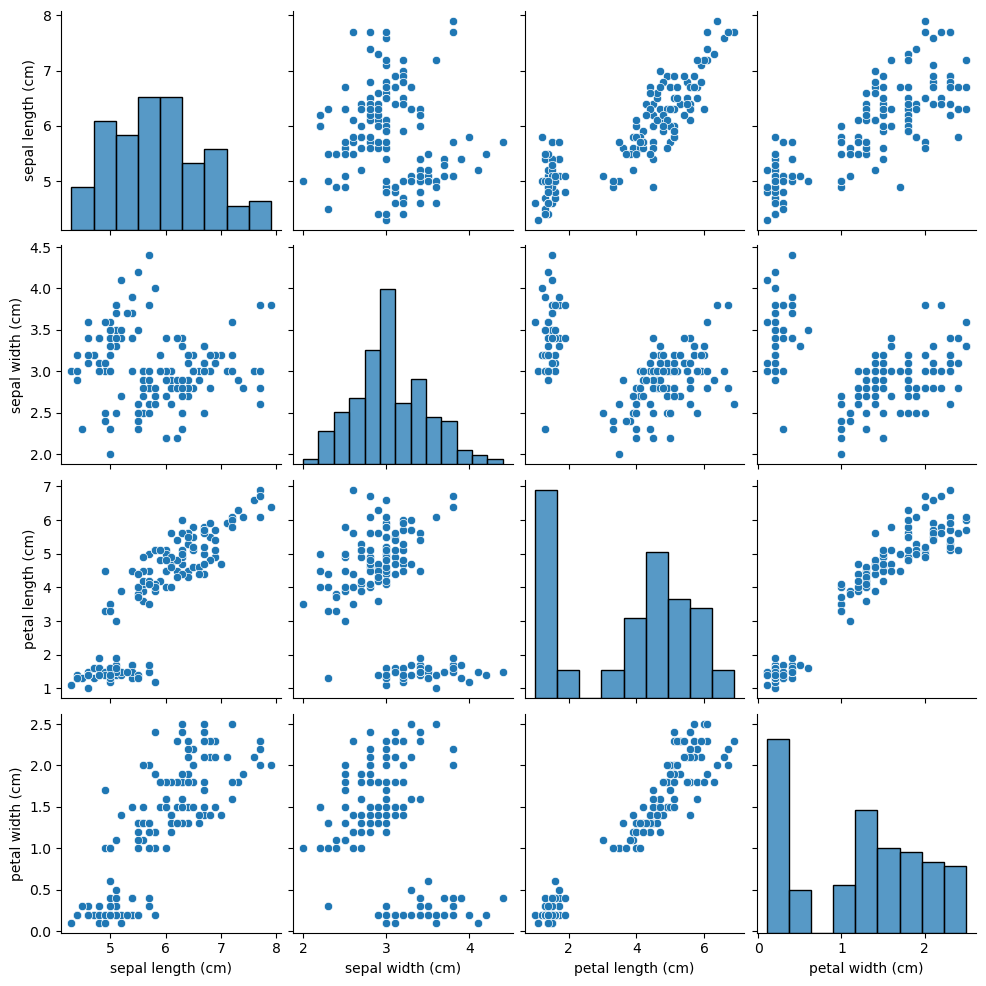

In [73]:
iris_db = datasets.load_iris(as_frame=True)
sn.pairplot(iris_db.data)

In [74]:
iris_db.data.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


We will split the data into train and test sets. For consistency and to allow for meaningful comparison the same splits are maintained in the remainder of the lab.

In [75]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    iris_db.data,
    iris_db.target,
    test_size=0.2,
    random_state=42
    )
x_train = torch.from_numpy(X_train.values).float()
x_test = torch.from_numpy(X_test.values).float()

y_train = torch.from_numpy(y_train.values).int()
y_train = y_train.reshape(-1, 1)

y_test = torch.from_numpy(y_test.values).int()
y_test = y_test.reshape(-1, 1)

<font color="red">**Q1.** We again notice that the attributes are on different scales. Use the normalisation method from last lab, to standardize the scales of each attribute on both sets. Plot the normalized and raw training sets; what do you observe? [2 marks] </font>

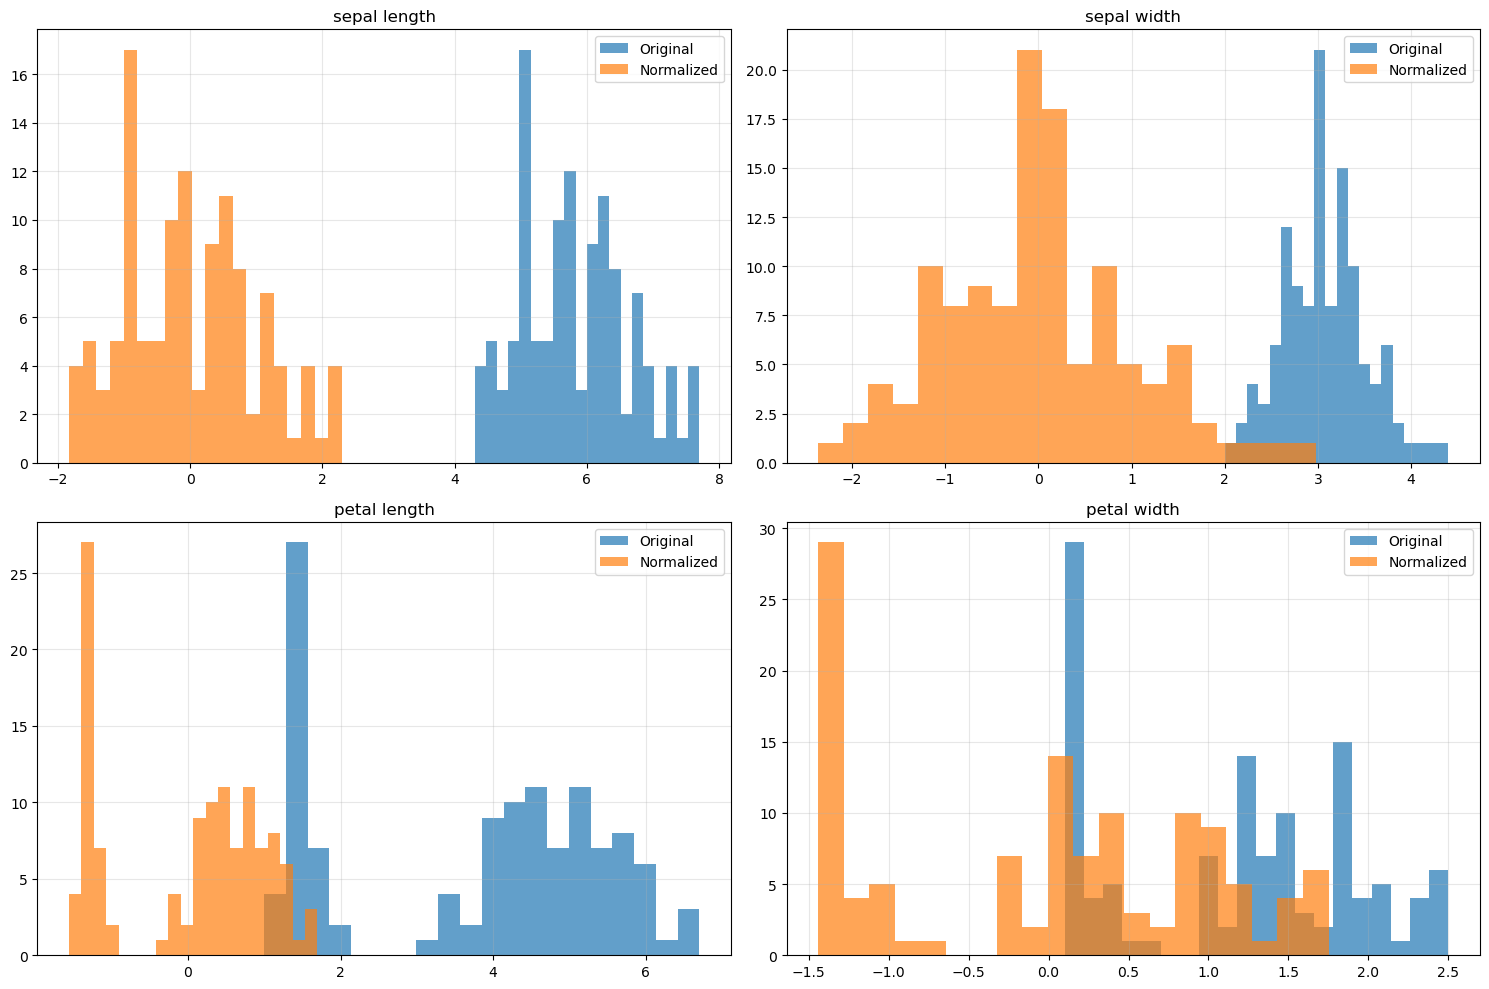

Original data statistics:
Mean: tensor([5.8092, 3.0617, 3.7267, 1.1833])
Std:  tensor([0.8238, 0.4491, 1.7523, 0.7523])

Normalized data statistics:
Mean: tensor([ 2.7716e-07, -1.2020e-07, -1.7136e-08,  6.3578e-08])
Std:  tensor([1., 1., 1., 1.])


In [76]:
### SOLUTION ###
def norm_set(x: torch.Tensor, mu: torch.Tensor, sigma: torch.Tensor) -> torch.tensor:
    return (x - mu) / sigma

# Store original data for comparison
x_train_original = x_train.clone()
x_test_original = x_test.clone()

# Calculate normalization parameters from training set
mu = torch.mean(x_train, dim=0)
sigma = torch.std(x_train, dim=0)

# Normalize both sets
x_train = norm_set(x_train, mu, sigma)
x_test = norm_set(x_test, mu, sigma)

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
feature_names = ['sepal length', 'sepal width', 'petal length', 'petal width']

for i in range(4):
    row, col = i // 2, i % 2
    
    axes[row, col].hist(x_train_original[:, i].numpy(), alpha=0.7, label='Original', bins=20)
    axes[row, col].hist(x_train[:, i].numpy(), alpha=0.7, label='Normalized', bins=20)
    axes[row, col].set_title(f'{feature_names[i]}')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Original data statistics:")
print(f"Mean: {torch.mean(x_train_original, dim=0)}")
print(f"Std:  {torch.std(x_train_original, dim=0)}")

print("\nNormalized data statistics:")
print(f"Mean: {torch.mean(x_train, dim=0)}")
print(f"Std:  {torch.std(x_train, dim=0)}")


By inspecting the dataset we see that it contains 4 attributes. (`sepal length`, `sepal width`, `petal length`, `petal width`, in centimeters). For simplicity we will focus on the first two.

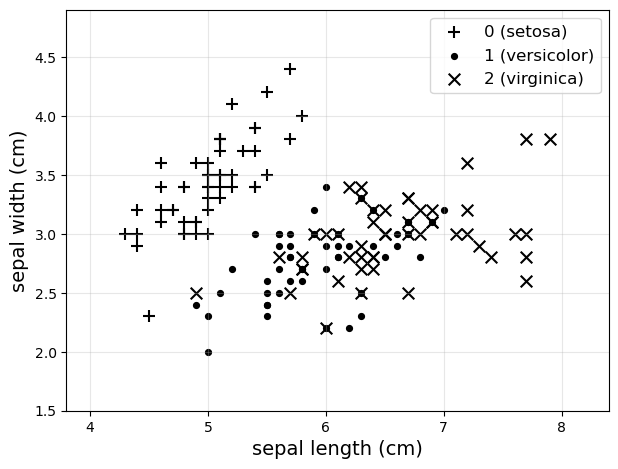

In [77]:
X = iris_db.data.iloc[:, :2]
Y = iris_db.target
marker_list = ['+', '.', 'x']
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111)
ax.set_aspect('equal')

for l in [0, 1, 2]:
  ax.scatter(
      X.loc[Y == l].iloc[:, 0],
      X.loc[Y == l].iloc[:, 1],
      marker=marker_list[l],
      s=70,
      color='black',
      label='{:d} ({:s})'.format(l, iris_db.target_names[l])
      )

ax.legend(fontsize=12)
ax.set_xlabel(iris_db.feature_names[0], fontsize=14)
ax.set_ylabel(iris_db.feature_names[1], fontsize=14)
ax.grid(alpha=0.3)
ax.set_xlim(X.iloc[:, 0].min() - 0.5, X.iloc[:, 0].max() + 0.5)
ax.set_ylim(X.iloc[:, 1].min() - 0.5, X.iloc[:, 1].max() + 0.5)
plt.show()

Is the data linearly separable?

In [78]:
print("The data shows three distinct clusters corresponding to the three iris species.")
print("Setosa (class 0) is clearly linearly separable from the other two classes.")

The data shows three distinct clusters corresponding to the three iris species.
Setosa (class 0) is clearly linearly separable from the other two classes.


As there are multiple classes, for now we will focus on class 0 (setosa). As such, we modify the `y_train` and `y_test` tensors, so that each label is 1 if the class is setosa and 0 if otherwise.

In [79]:
train_set_1 = x_train[:, :2]
test_set_1 = x_test[:, :2]

# add a feature for bias
train_set_1 = torch.cat([train_set_1, torch.ones(train_set_1.shape[0], 1)], dim=1)
test_set_1 = torch.cat([test_set_1, torch.ones(test_set_1.shape[0], 1)], dim=1)

setosa_train = (y_train == 0).int().float()
setosa_test = (y_test == 0).int().float()

print(f"Training set shape: {train_set_1.shape}")
print(f"Binary labels - Setosa count in train: {setosa_train.sum().item()}/{len(setosa_train)}")
print(f"Binary labels - Setosa count in test: {setosa_test.sum().item()}/{len(setosa_test)}")

Training set shape: torch.Size([120, 3])
Binary labels - Setosa count in train: 40.0/120
Binary labels - Setosa count in test: 10.0/30


## 1. Sigmoid function
With logistic regression the values we want to predict are now discrete classes, not continuous variables. In other words, logistic regression is for classification tasks. In the binary classification problem we have classes $0$ and $1$, e.g. classifying email as spam or not spam based on words used in the email.

The logistic/sigmoid function given by the formula below:

$ h_{\theta}(x) = g(\theta^{T}x) =  \frac{1}{1+ e^{-\theta^Tx}} $

**Q2.** First implement the above function in `def sigmoid()`. [2 marks]

**Q3.** Then, using the implementation of `LinearRegression` from last week as guideline, create a custom pytorch layer for `LogisticRegression` [2 marks]

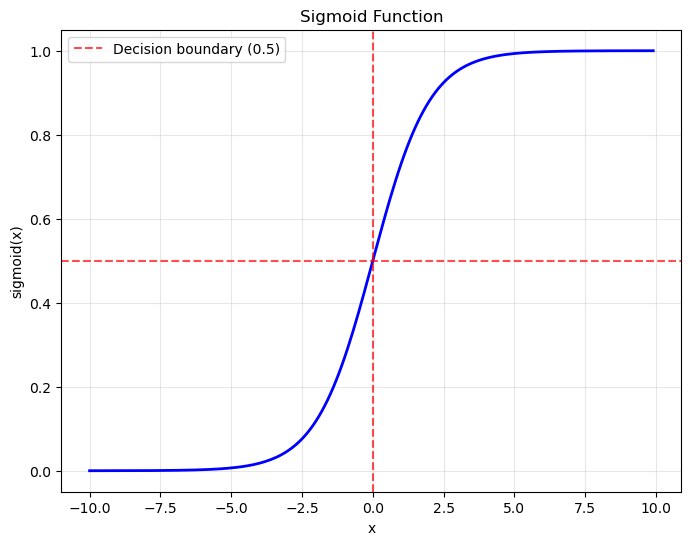

In [80]:
### SOLUTION ###
def sigmoid(z: torch.Tensor) -> torch.Tensor:
    # Sigmoid function: σ(z) = 1 / (1 + e^(-z))
    # Use torch.clamp to prevent overflow
    z = torch.clamp(z, -500, 500)  # Prevent overflow
    return 1.0 / (1.0 + torch.exp(-z))

# Test sigmoid function
x = torch.arange(-10, 10, 0.1)
y = sigmoid(x)
fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(x, y, 'b-', linewidth=2)
ax1.set_xlabel('x')
ax1.set_ylabel('sigmoid(x)')
ax1.set_title('Sigmoid Function')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0.5, color='r', linestyle='--', alpha=0.7, label='Decision boundary (0.5)')
ax1.axvline(x=0, color='r', linestyle='--', alpha=0.7)
ax1.legend()
plt.show()


In [81]:
### SOLUTION ###
class LogisticRegression(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    # Initialize weights randomly (small values)
    self.weight = nn.Parameter(torch.randn(1, num_features) * 0.01, requires_grad=False)

  def forward(self, x):
    # logits = X @ w^T   → shape [N,1]
    logits = x @ self.weight.T
    # probability of class 1
    return torch.sigmoid(logits)

# Test the logistic regression model
model_test = LogisticRegression(train_set_1.shape[1])
test_output = model_test(train_set_1[:5])
print(f"Test output shape: {test_output.shape}")
print(f"Test output values: {test_output.flatten()}")
print(f"All outputs in (0,1): {torch.all((test_output > 0) & (test_output < 1))}")

Test output shape: torch.Size([5, 1])
Test output values: tensor([0.5023, 0.5052, 0.5010, 0.5017, 0.5009])
All outputs in (0,1): True


The cost function we will use for logistic regression is the **Cross Entropy Loss**, which is given by the form:

$J(\theta) = \frac{1}{m} \sum_{i=1}^m \left[ \left(- y^{(i)} log( h_{\theta}(x^{(i)})) - (1-y^{(i)})log(1-h_{\theta}(x^{(i)}))    \right) \right] $

Which when taking partial derivatives and putting these into the gradient descent update equation gives


$
 \theta_{j} =  \theta_{j} - \alpha \frac{1}{m}  \sum_{i=1}^m ( h_{\theta}(x^{(i)}) - y^{(i)})x^{(i)}_{j}
$

**Q4.** Implement the cost in `bce()` and update the `gradient_descent_step()` from last week to update using the partial derivative above. [4 marks]

In [82]:
### SOLUTION ###
def bce(y_true: torch.Tensor, y_pred: torch.Tensor) -> torch.Tensor:
    # Binary cross-entropy on probabilities
    # y_true, y_pred: shape [N,1], y_true in {0,1}
    eps = 1e-8
    p = y_pred.clamp(min=eps, max=1 - eps)     # numerically safer than adding eps inside logs
    return -(y_true * torch.log(p) + (1 - y_true) * torch.log(1 - p)).mean()

def gradient_descent_step(model: nn.Module, X: torch.Tensor, y: torch.Tensor, lr: float) -> None:
    N = X.shape[0]
    y = y.float().view(-1, 1)                   # ensure [N,1] float
    y_pred = model(X)                           # sigmoid probabilities
    residuals = y_pred - y                      # [N,1]
    grad = (residuals.T @ X) / N                # [1,F]
    new_w = model.weight - lr * grad
    model.weight = torch.nn.Parameter(new_w, requires_grad=False)

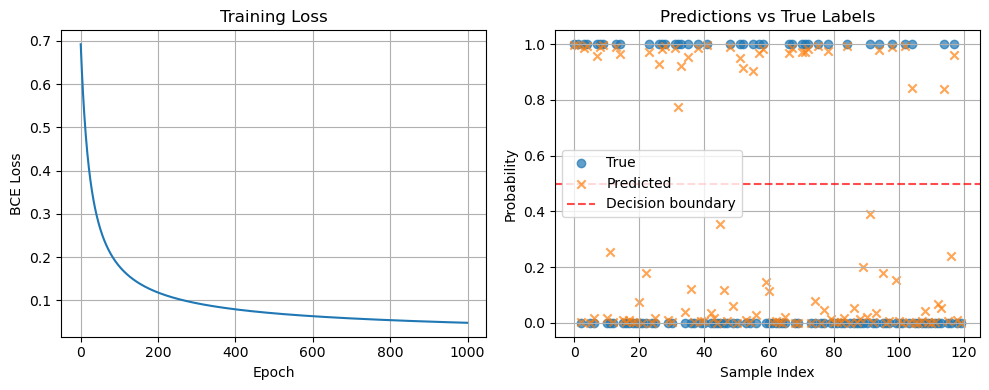

Final weights: [-3.76641    2.5406392 -2.1242952]
Minimum cost: 0.0479


In [83]:
def train(model, x, y, alpha, epochs=1000):
    # ensure labels are float column vectors to match sigmoid output
    y = y.float().view(-1, 1)

    cost_lst = []
    for it in range(epochs):
        # forward (for logging)
        with torch.no_grad():
            pred = model(x)                 # [N,1]
            cost = bce(y, pred)             # your BCE on probabilities
            cost_lst.append(cost.item())
        gradient_descent_step(model, x, y, alpha)

    # ---- Plots ----
    with torch.no_grad():
        final_pred = model(x)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(range(len(cost_lst)), cost_lst)
    plt.title('Training Loss')
    plt.xlabel('Epoch'); plt.ylabel('BCE Loss'); plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.scatter(range(len(y)), y.numpy(), alpha=0.7, label='True', marker='o')
    plt.scatter(range(len(y)), final_pred.numpy(), alpha=0.7, label='Predicted', marker='x')
    plt.axhline(0.5, color='r', linestyle='--', alpha=0.7, label='Decision boundary')
    plt.title('Predictions vs True Labels')
    plt.xlabel('Sample Index'); plt.ylabel('Probability')
    plt.legend(); plt.grid(True)

    plt.tight_layout(); plt.show()

    print('Final weights:', model.weight.detach().numpy().ravel())
    print(f'Minimum cost: {min(cost_lst):.4f}')
    return cost_lst

model = LogisticRegression(train_set_1.shape[1])
alpha = 0.1 
cost_history = train(model, train_set_1, setosa_train, alpha)

<font color="red"> **Q5.** Draw the decision boundary on the test set using the learned parameters. Is this decision boundary separating the classes? Does this match our expectations? [2 marks]</font>

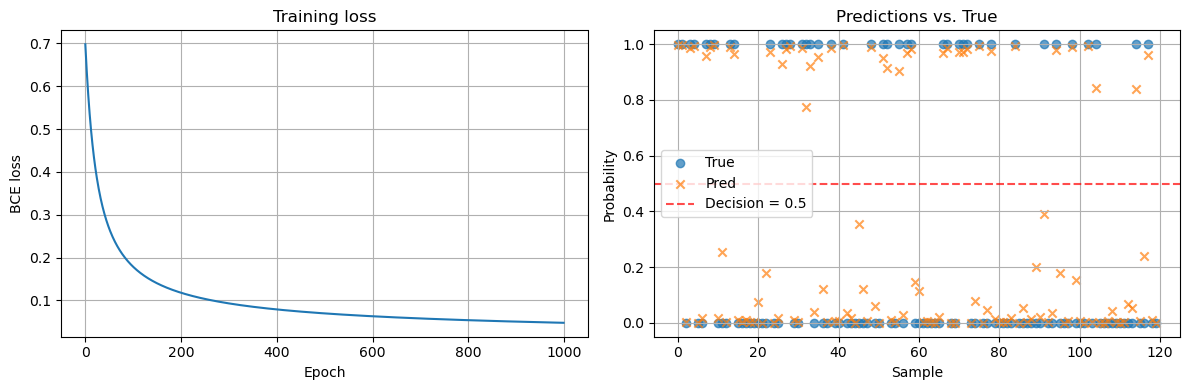

Final weights: [-3.765805   2.5405138 -2.1238818]
Minimum loss: 0.0479
Test Accuracy: 1.0000 (100.0%)


In [84]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def train(model, X, y, lr, epochs=1000):
    # Ensure correct dtype/shape for labels
    y = y.float().view(-1, 1)

    cost_hist = []
    for it in range(epochs):
        # forward & loss
        with torch.no_grad():                 # no grads needed just to record loss curve
            y_pred = model(X)                 # [N,1] probabilities
            cost = bce(y, y_pred)             # BCE on probabilities
            cost_hist.append(cost.item())

        # one GD step (computes preds internally)
        gradient_descent_step(model, X, y, lr)

        # simple divergence guard
        if not np.isfinite(cost_hist[-1]):
            print(f"Diverged at epoch {it} (try a smaller lr).")
            break

    # ---- Plots ----
    with torch.no_grad():
        y_pred_final = model(X).detach().cpu().numpy().reshape(-1)
    y_np = y.detach().cpu().numpy().reshape(-1)

    plt.figure(figsize=(12, 4))

    # Loss curve
    plt.subplot(1, 2, 1)
    plt.plot(range(len(cost_hist)), cost_hist)
    plt.xlabel("Epoch"); plt.ylabel("BCE loss"); plt.title("Training loss")
    plt.grid(True)

    # Predicted probabilities vs. true labels
    plt.subplot(1, 2, 2)
    idx = np.arange(len(y_np))
    plt.scatter(idx, y_np, label="True", alpha=0.7, marker='o')
    plt.scatter(idx, y_pred_final, label="Pred", alpha=0.7, marker='x')
    plt.axhline(0.5, color='r', linestyle='--', alpha=0.7, label='Decision = 0.5')
    plt.xlabel("Sample"); plt.ylabel("Probability"); plt.title("Predictions vs. True")
    plt.legend(); plt.grid(True)

    plt.tight_layout(); plt.show()

    print("Final weights:", model.weight.detach().cpu().numpy().ravel())
    print(f"Minimum loss: {min(cost_hist):.4f}")
    return cost_hist

# ---- Training ----
model = LogisticRegression(train_set_1.shape[1])  # ensure bias handling is consistent with your pipeline
alpha = 0.1                                       # 1.0 is often too large; start smaller
cost_history = train(model, train_set_1, setosa_train, alpha, epochs=1000)

# ---- Evaluation on test set ----
with torch.no_grad():
    probs = model(test_set_1)                      # [N,1] probabilities
    preds = (probs >= 0.5).float()                 # threshold at 0.5

y_true = setosa_test.float().view(-1, 1)
accuracy = preds.eq(y_true).float().mean().item()
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")


In [85]:
# sanity check
with torch.no_grad():
    probs = model(test_set_1).view(-1)
preds = (probs >= 0.5).float()
y = setosa_test.view(-1).float()

# Confusion matrix
tp = ((preds==1)&(y==1)).sum().item()
tn = ((preds==0)&(y==0)).sum().item()
fp = ((preds==1)&(y==0)).sum().item()
fn = ((preds==0)&(y==1)).sum().item()
print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")

# How confident are predictions?
margin = (probs - 0.5).abs()
print("Min |p-0.5|:", float(margin.min()))
print("Mean |p-0.5|:", float(margin.mean()))


TP=10, TN=20, FP=0, FN=0
Min |p-0.5|: 0.34028273820877075
Mean |p-0.5|: 0.46311813592910767


## 2. Multiclass
So far, we have focused on a binary classification (is this iris setosa or not), however in this section we will address the problem as a multiclass classification. We will be using a 1 vs. all approach (refer to the lecture notes for details). We will also be using all 4 attributes for the classification.

Firstly, we need to process `y_train, y_test` so that each label is a vector rather than an integer.

In [86]:
y_train = F.one_hot(y_train.reshape(-1).long(), num_classes=3)
y_test = F.one_hot(y_test.reshape(-1).long(), num_classes=3)
print(y_test.shape)

torch.Size([30, 3])


In this section we will use the built in pytorch methods.


In [87]:
alpha = 0.1
setosa_model = nn.Sequential(nn.Linear(x_train.shape[1], 1, bias=False), nn.Sigmoid())
setosa_labels = y_train[:, 0].reshape(-1, 1).float()
setosa_testy = y_test[:, 0].reshape(-1, 1).float()
optimiser = optim.SGD(setosa_model.parameters(), alpha)

def train(model, x, y, test_x, test_y, optimiser, alpha):
  train_lst = list()
  test_lst = list()
  for i in range(1000):
    model.train()
    optimiser.zero_grad()
    pred = model(x)
    cost = F.binary_cross_entropy(pred, y, reduction='mean')
    cost.backward()
    train_lst.append(cost.item())
    optimiser.step()
    model.eval()
    with torch.no_grad():
      test_pred = model(test_x)
      test_cost = F.binary_cross_entropy(test_pred, test_y, reduction='mean')
      test_lst.append(test_cost)
  fig, axs = plt.subplots(2)
  axs[0].plot(list(range(i+1)), train_lst)
  axs[1].plot(list(range(i+1)), test_lst)
  plt.show()
  print('Minimum train cost: {}'.format(min(train_lst)))
  print('Minimum test cost: {}'.format(min(test_lst)))


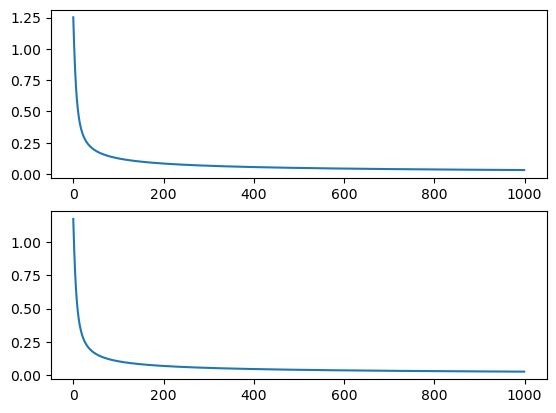

Minimum train cost: 0.032227203249931335
Minimum test cost: 0.02726740948855877


In [88]:
train(setosa_model, x_train, setosa_labels, x_test, setosa_testy, optimiser, alpha)

How does the cost of the 4 attribute model compare to the previous one?

**Q6** Now train classifiers for the other two classes.[1 mark]

Training Versicolor classifier


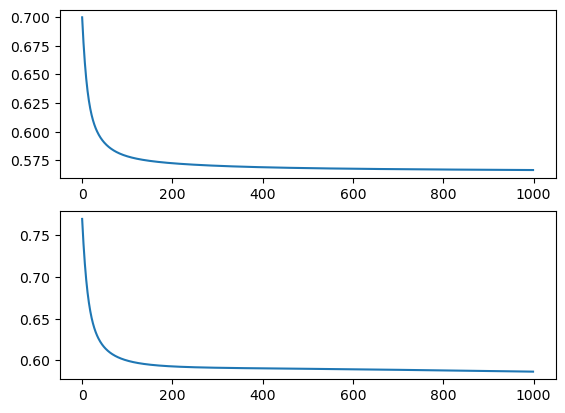

Minimum train cost: 0.5666337609291077
Minimum test cost: 0.5865601897239685
Training Virginica classifier


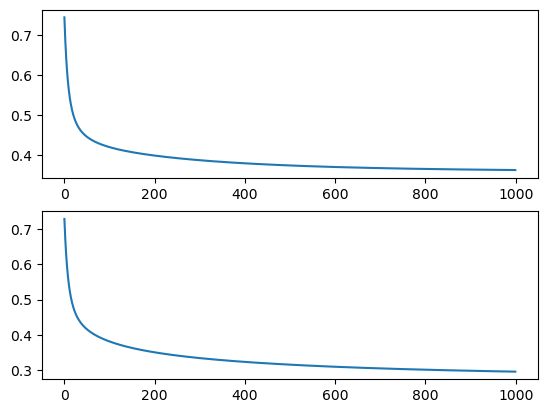

Minimum train cost: 0.36191076040267944
Minimum test cost: 0.2948998808860779


In [89]:
versicolor_model = nn.Sequential(nn.Linear(x_train.shape[1], 1, bias=False), nn.Sigmoid())
virginica_model = nn.Sequential(nn.Linear(x_train.shape[1], 1, bias=False), nn.Sigmoid())

versicolor_labels = y_train[:, 1].reshape(-1, 1).float()
virginica_labels = y_train[:, 2].reshape(-1, 1).float()

versicolor_test = y_test[:, 1].reshape(-1, 1).float()
virginica_test = y_test[:, 2].reshape(-1, 1).float()

versicolor_optim = optim.SGD(versicolor_model.parameters(), alpha)
virginica_optim = optim.SGD(virginica_model.parameters(), alpha)

print('Training Versicolor classifier')
train(versicolor_model, x_train, versicolor_labels, x_test, versicolor_test, versicolor_optim, alpha)
print('Training Virginica classifier')
train(virginica_model, x_train, virginica_labels, x_test, virginica_test, virginica_optim, alpha)

<font color="red"> **Q7.** Using the 3 classifiers, predict the classes of the samples in the test set and show the predictions in a table. Do you observe anything interesting? [4 marks] </font>

In [90]:
with torch.no_grad():
  setosa_scores = setosa_model(x_test)
  versicolor_scores = versicolor_model(x_test)
  virginica_scores = virginica_model(x_test)

  combined_scores = torch.cat([setosa_scores, versicolor_scores, virginica_scores], dim=1)
  predicted_classes = torch.argmax(combined_scores, dim=1)
  actual_classes = torch.argmax(y_test, dim=1)

  results_table = pd.DataFrame({
      'Setosa_prob': setosa_scores.squeeze().cpu().numpy(),
      'Versicolor_prob': versicolor_scores.squeeze().cpu().numpy(),
      'Virginica_prob': virginica_scores.squeeze().cpu().numpy(),
      'Predicted_class': predicted_classes.cpu().numpy(),
      'Actual_class': actual_classes.cpu().numpy()
  })

print(results_table.head())
print('\nFull prediction table:')
display.display(results_table)

   Setosa_prob  Versicolor_prob  Virginica_prob  Predicted_class  Actual_class
0     0.035599         0.752885        0.466748                1             1
1     0.999957         0.169560        0.113082                0             0
2     0.000003         0.839403        0.947549                2             2
3     0.038484         0.591208        0.704640                2             1
4     0.007766         0.766506        0.542786                1             1

Full prediction table:


,Setosa_prob,Versicolor_prob,Virginica_prob,Predicted_class,Actual_class
0,0.035599,0.752885,0.466748,1,1
1,0.999957,0.169560,0.113082,0,0
2,0.000003,0.839403,0.947549,2,2
3,0.038484,0.591208,0.704640,2,1
4,0.007766,0.766506,0.542786,1,1
5,0.999644,0.305884,0.081848,0,0
6,0.283528,0.541376,0.523993,1,1
7,0.001853,0.355126,0.966925,2,2
8,0.000448,0.912317,0.391214,1,1
9,0.077485,0.732455,0.375976,1,1


<font color="red"> **Q8.** Calculate the accuracy of the classifier on the test set, by comparing the predicted values against the ground truth. Use a softmax for the classifier outputs. [1 mark] </font>

In [91]:
with torch.no_grad():
  setosa_scores = setosa_model(x_test)
  versicolor_scores = versicolor_model(x_test)
  virginica_scores = virginica_model(x_test)
  combined_scores = torch.cat([setosa_scores, versicolor_scores, virginica_scores], dim=1)

  eps = 1e-8
  logits = torch.log(combined_scores + eps) - torch.log(1 - combined_scores + eps)
  softmax_outputs = torch.softmax(logits, dim=1)
  predicted_classes = torch.argmax(softmax_outputs, dim=1)
  actual_classes = torch.argmax(y_test, dim=1)
  accuracy = (predicted_classes == actual_classes).float().mean().item()

print(f'Test accuracy using softmax aggregation: {accuracy:.4f}')


Test accuracy using softmax aggregation: 0.9000


## 3. The XOR problem

<font color="red"> **Q9.** Looking at the datapoints below, can we draw a decision boundary using Logistic Regression? Why? What are the specific issues or logistic regression with regards to XOR? [2 marks] </font>

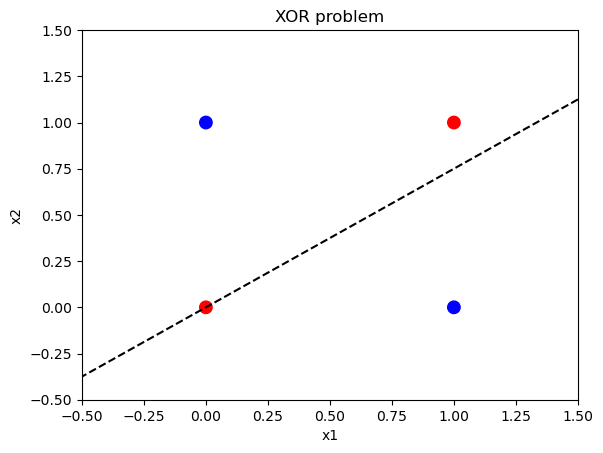

Logistic regression fails on the XOR dataset because the classes are not linearly separable.
Its linear decision boundary cannot split the diagonally opposite points.
The issue arises from the lack of interaction modeling and linear dependence in the model.
A nonlinear model (e.g., neural network or polynomial logistic regression) is required to solve XOR correctly.


In [92]:

x1 = np.array([0,0,1,1])
x2 = np.array([0,1,0,1])
y  = np.array([0,1,1,0])
cmap = ['r' if label==0 else 'b' for label in y]

plt.scatter(x1, x2, c=cmap, s=80)
plt.xlabel('x1'); plt.ylabel('x2'); plt.title('XOR problem')

# Decision grid (linear model cannot separate properly)
xx, yy = np.meshgrid(np.linspace(-0.5,1.5,50), np.linspace(-0.5,1.5,50))
zz = 0.5 + 0.3*xx - 0.4*yy  # random linear boundary
plt.contour(xx, yy, zz, levels=[0.5], colors='k', linestyles='--')
plt.show()

print('Logistic regression fails on the XOR dataset because the classes are not linearly separable.')
print('Its linear decision boundary cannot split the diagonally opposite points.')
print('The issue arises from the lack of interaction modeling and linear dependence in the model.')
print('A nonlinear model (e.g., neural network or polynomial logistic regression) is required to solve XOR correctly.')